# Unsupervised Learning

In unsupervised learning, you have data ($X$) but no labels ($y$). The algorithm's job is to discover the hidden structure, patterns, or groupings within the data.

## 1. Clustering: K-Means

K-Means tries to partition the data into $K$ distinct clusters. 
1. It randomly places $K$ cluster centers (centroids).
2. Assigns each point to the nearest centroid.
3. Moves the centroid to the mean of all points assigned to it.
4. Repeats until convergence.

Text(0.5, 1.0, 'K-Means Clustering (K=3)')

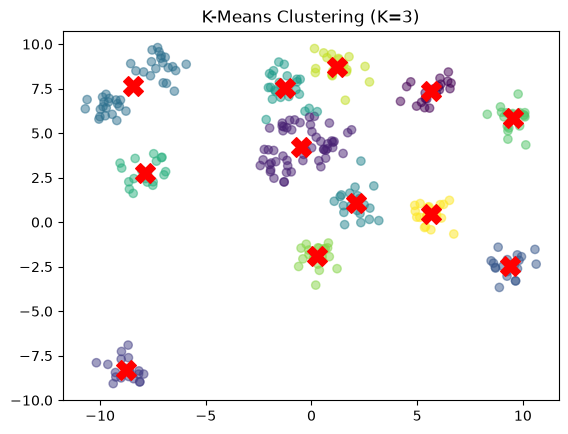

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate fake data with 3 distinct "blobs" (clusters)
X, _ = make_blobs(n_samples=300, centers=15, cluster_std=0.60, random_state=0)

# We must tell K-Means how many clusters (K) to look for
kmeans = KMeans(n_clusters=12, random_state=1)
kmeans.fit(X)

# Get the predicted cluster for each point
labels = kmeans.predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.5)
# Plot the centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.title("K-Means Clustering (K=3)")
# plt.show()

### How to choose K? (The Elbow Method)
Run K-Means for $K=1, 2, 3...10$. Calculate the sum of squared distances from each point to its assigned center (Inertia). Plot the inertia. The point where the curve bends (the "elbow") is usually the optimal $K$.

## 2. Density-Based Clustering: DBSCAN

K-Means forces every point into a cluster and assumes clusters are spherical. **DBSCAN** groups together points that are closely packed together, marking points in low-density regions as outliers (noise). You don't need to specify $K$!

Text(0.5, 1.0, 'DBSCAN Clustering (handles non-spherical shapes)')

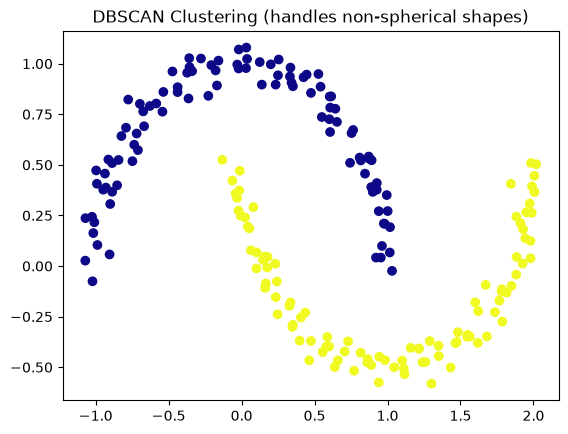

In [22]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generate crescent moon shaped data (K-Means fails miserably on this)
X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=0)

# eps = maximum distance between two samples to be considered in the same neighborhood
dbscan = DBSCAN(eps=0.3, min_samples=5)
db_labels = dbscan.fit_predict(X_moons)

plt.figure()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=db_labels, cmap='plasma')
plt.title("DBSCAN Clustering (handles non-spherical shapes)")
# plt.show()

## 3. Dimensionality Reduction: PCA

Principal Component Analysis (PCA) reduces the number of features in your dataset while retaining as much variance (information) as possible.

**Why use PCA?**
1. Data visualization (compressing 100 dimensions down to 2 or 3 to plot them).
2. Speeding up algorithms by removing redundant or highly correlated features.

In [24]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load Iris dataset (4 features: sepal length/width, petal length/width)
iris = load_iris()
X_iris = iris.data

# Reduce from 4 dimensions down to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

print(f"Original shape: {X_iris.shape}")
print(f"Reduced shape: {X_pca.shape}")

# How much information did we keep?
variance_ratio = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {variance_ratio[0]*100:.1f}%")
print(f"Variance explained by PC2: {variance_ratio[1]*100:.1f}%")
print(f"Total variance retained: {sum(variance_ratio)*100:.1f}%")

Original shape: (150, 4)
Reduced shape: (150, 2)
Variance explained by PC1: 92.5%
Variance explained by PC2: 5.3%
Total variance retained: 97.8%


---
## References
*   [Scikit-Learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
*   [Scikit-Learn: PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca)